# Курс "Программирование на Python"


# Практическое задание №4 (опциональное, 2 балла)

## Часть 1. Библиотека numpy

Проанализируйте эффективность компании по найму сотрудников. У вас в распоряжении следующие данные по каждому кандидату:
- длительность процедуры найма в днях;
- количество этапов прохождения собеседований;
- оценка кандидата (по шкале от 0 до 100);
- зарплатные ожидания кандидатов (в тыс. рублей);
- кандидат принят (True если да);
- код отдела (от 0 до 3).

In [134]:
import numpy as np  # генерируем данные

np.random.seed(42)  # для воспроизводимости

n = 1000

# 0: время найма (5–60 дней)
time_to_hire = np.random.randint(5, 61, size=n)

# 1: этапы (1–7)
stages = np.random.randint(1, 8, size=n)

# 2: оценка (0–100)
scores = np.random.uniform(40, 100, size=n)

# 3: ожидания по зарплате (50–150 тыс.)
salary_expect = np.random.uniform(50, 150, size=n)

# 4: принят (с вероятностью 0.4)
accepted = np.random.choice([0, 1], size=n, p=[0.6, 0.4])

# 5: отдел (0 — маркетинг, 1 — разработка, 2 — продажи, 3 — HR)
departments = np.random.randint(0, 4, size=n)

# Формируем финальный массив
data = np.column_stack((time_to_hire, stages, scores, salary_expect, accepted, departments))

In [135]:
print(data)

[[ 43.           4.          92.85224555  84.79414116   0.
    3.        ]
 [ 56.           4.          92.31061166  95.03509789   1.
    0.        ]
 [ 33.           1.          41.75483698 124.8826337    0.
    2.        ]
 ...
 [ 15.           4.          46.03824871  94.25455148   0.
    2.        ]
 [ 58.           7.          54.39244677 114.93223246   0.
    2.        ]
 [ 20.           5.          48.51831939 143.62806215   0.
    1.        ]]


In [136]:
data.shape

(1000, 6)

Определите следующее:
1. среднее, медианное и стандартное отклонение времени найма по всей выборке;
2. есть ли разница в среднем времени найма между принятыми и отклонёнными кандидатами;
3. среднюю оценку кандидатов, прошедших более 4 этапов;
4. долю принятых кандидатов с оценкой выше 80;
5. среднюю оценку и долю принятых по отделам.

In [137]:
# код здесь  (￣▽￣)/♫•*¨*•.¸¸♪ 

# Преобразуем данные в DataFrame
import pandas as pd
df = pd.DataFrame(data, columns=['time_to_hire', 'stages', 'scores', 'salary_expect', 'accepted', 'department'])

# Cреднее, медианное и стандартное отклонение времени найма
print(f'Среднее время найма: {df['time_to_hire'].mean():.2f}')
print(f'Медианное время найма: {df['time_to_hire'].median():.2f}')
print(f'Стандартное отклонение времени найма: {df['time_to_hire'].std():.2f}\n')

# Разница в среднем времени между принятыми и отклонёнными кандидатами
status_time = df.groupby('accepted')['time_to_hire'].mean()
difference = status_time[1] - status_time[0]

print(f'Среднее время найма принятых кандидатов: {status_time[0]:.2f} дней')
print(f'Среднее время найма отклоненных кандидатов: {status_time[1]:.2f} дней')
print(f'Разница в среднем времени найма: {difference:.2f} дней\n')

# Средняя оценка кандидатов, прошедших более 4 этапов
high_stages = df[df['stages'] > 4]
print(f'Средняя оценка кандидатов, прошедших >4 этапов: {high_stages['scores'].mean():.2f}')

# Доля принятых кандидатов с оценкой выше 80
high_scores = df[df['scores'] > 80]
accepted_high_scores = high_scores[high_scores['accepted'] == 1]

print(f'Доля принятых кандидатов с оценкой >80: {len(accepted_high_scores) / len(high_scores):.2%}\n')

# Средняя оценка и доля принятых по отделам
dept_stats = df.groupby('department').agg(
    Средняя_оценка=('scores', 'mean'),
    Доля_принятых=('accepted', 'mean')
).round(2)

dept_names = {0: 'Маркетинг', 1: 'Разработка', 2: 'Продажи', 3: 'HR'}
dept_stats.index = dept_stats.index.map(dept_names)
dept_stats.index.name = None

print(f'Статистика по отделам:')
print(dept_stats)

Среднее время найма: 32.85
Медианное время найма: 33.00
Стандартное отклонение времени найма: 16.07

Среднее время найма принятых кандидатов: 32.01 дней
Среднее время найма отклоненных кандидатов: 34.16 дней
Разница в среднем времени найма: 2.15 дней

Средняя оценка кандидатов, прошедших >4 этапов: 70.28
Доля принятых кандидатов с оценкой >80: 37.20%

Статистика по отделам:
            Средняя_оценка  Доля_принятых
Маркетинг            71.39           0.38
Разработка           69.27           0.40
Продажи              69.55           0.41
HR                   70.17           0.38


### Альтернативное решение (без создания df)

In [138]:
import numpy as np  # генерируем данные

np.random.seed(42)  # для воспроизводимости

n = 1000

# 0: время найма (5–60 дней)
time_to_hire = np.random.randint(5, 61, size=n)

# 1: этапы (1–7)
stages = np.random.randint(1, 8, size=n)

# 2: оценка (0–100)
scores = np.random.uniform(40, 100, size=n)

# 3: ожидания по зарплате (50–150 тыс.)
salary_expect = np.random.uniform(50, 150, size=n)

# 4: принят (с вероятностью 0.4)
accepted = np.random.choice([0, 1], size=n, p=[0.6, 0.4])

# 5: отдел (0 — маркетинг, 1 — разработка, 2 — продажи, 3 — HR)
departments = np.random.randint(0, 4, size=n)

# Формируем финальный массив
data = np.column_stack((time_to_hire, stages, scores, salary_expect, accepted, departments))

In [139]:
# Передаем колонки в отдельные переменные
time_to_hire = data[:, 0]
stages = data[:, 1]
scores = data[:, 2]
salary_expect = data[:, 3]
accepted = data[:, 4]
departments = data[:, 5]

# Cреднее, медианное и стандартное отклонение времени найма
print(f'Среднее время найма: {np.mean(time_to_hire):.2f}')
print(f'Медианное время найма: {np.median(time_to_hire):.2f}')
print(f'Стандартное отклонение время найма: {np.std(time_to_hire):.2f}\n')

# Разница в среднем времени между принятыми и отклонёнными кандидатами
rejected_mask = accepted == 0
accepted_mask = accepted == 1

mean_time_rejected = np.mean(time_to_hire[rejected_mask])
mean_time_accepted = np.mean(time_to_hire[accepted_mask])
difference = mean_time_accepted - mean_time_rejected

print(f'Среднее время найма принятых кандидатов: {np.mean(time_to_hire[rejected_mask]):.2f} дней')
print(f'Среднее время найма отклоненных кандидатов: {np.mean(time_to_hire[accepted_mask]):.2f} дней')
print(f'Разница в среднем времени найма: {difference:.2f} дней\n')

# Средняя оценка кандидатов, прошедших более 4 этапов
print(f'Средняя оценка кандидатов, прошедших >4 этапов: {np.mean(scores[stages > 4]):.2f}')

# Доля принятых кандидатов с оценкой выше 80
acceptance_rate = np.sum(scores > 80 & (accepted == 1)) / np.sum(scores > 80)
print(f'Доля принятых кандидатов с оценкой >80: {acceptance_rate:.2%}\n')

# Средняя оценка и доля принятых по отделам
print(f'Статистика по отделам:')
dept_names = {0: 'Маркетинг', 1: 'Разработка', 2: 'Продажи', 3: 'HR'}

for dept in range(4):
    dept_mask = departments == dept
    dept_scores = scores[dept_mask]
    dept_accepted = accepted[dept_mask]
    
    avg_score = np.mean(dept_scores)
    acceptance_rate = np.mean(dept_accepted)
    
    print(f'{dept_names[dept]:10}  {avg_score:13.3f}  {acceptance_rate:12.2%}')

Среднее время найма: 32.85
Медианное время найма: 33.00
Стандартное отклонение время найма: 16.06

Среднее время найма принятых кандидатов: 32.01 дней
Среднее время найма отклоненных кандидатов: 34.16 дней
Разница в среднем времени найма: 2.15 дней

Средняя оценка кандидатов, прошедших >4 этапов: 70.28
Доля принятых кандидатов с оценкой >80: 297.62%

Статистика по отделам:
Маркетинг          71.392        37.70%
Разработка         69.266        39.83%
Продажи            69.554        40.50%
HR                 70.170        38.14%


## Часть 2. Библиотека pandas

Проанализируйте данные о вакансиях на глобальном рынке труда в сфере ИИ в 2025 году.

[Источник](https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025)

В файле `ai_job_dataset.csv` содержатся следующие переменные:


- job_id: Unique identifier for each job posting
- job_title: Standardized job title	
- salary_usd:	Annual salary in USD	
- salary_currency:	Original salary currency	
- salary_local:	Salary in local currency	
- experience_level:	EN (Entry), MI (Mid), SE (Senior), EX (Executive)	
- employment_type:	FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance)	
- company_location:	Country where company is located	
- company_size:	S (Small <50), M (Medium 50-250), L (Large >250)	
- employee_residence:	Country where employee resides	
- remote_ratio:	0 (No remote), 50 (Hybrid), 100 (Fully remote)	
- required_skills:	Top 5 required skills (comma-separated)	
- education_required:	Minimum education requirement	
- years_experience:	Required years of experience	
- industry:	Industry sector of the company	
- posting_date:	Date when job was posted	
- application_deadline:	Application deadline	
- job_description_length:	Character count of job description	
- benefits_score:	Numerical score of benefits package (1-10)	

In [140]:
import pandas as pd

1. Опишите датасет (число наблюдений и переменных, пропущенных значений, типы данных, типы шкал переменных).

In [141]:
# код здесь  ≽^•⩊•^≼ 
df = pd.read_csv('ai_job_dataset.csv')

print("Размер датасета:", df.shape)
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nТипы данных:")
print(df.dtypes)

Размер датасета: (15000, 19)

Пропущенные значения:
job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

Типы данных:
job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_requi

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

2. Отобразите первые пять строк и последние три строки датасета.

In [143]:
# код здесь (˶ᵔ ᵕ ᵔ˶)
# Первые пять строк датасета
df.head(5)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [144]:
# Последние три строки датасета 
df.tail(3)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


3. Установите идентификатор вакансии (job_id) как индекс строк.

In [145]:
# код здесь ♡‧₊˚✧ ૮ ˶ᵔ ᵕ ᵔ˶ ა ✧˚₊‧♡
df.set_index('job_id', inplace=True)
df.head(3)

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
job_id,,,,,,,,,,,,,,,,,,
AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech


4. Выведите список названий столбцов таблицы.

In [146]:
# код здесь (ᵔ◡ᵔ)
print(df.columns.tolist())

['job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']


5. Выведите информацию о проценте непустых ячеек в каждом столбце.

In [147]:
# код здесь ☆ﾟ.*･｡ﾟ
print((1 - df.isnull().sum() / len(df)) * 100)

job_title                 100.0
salary_usd                100.0
salary_currency           100.0
experience_level          100.0
employment_type           100.0
company_location          100.0
company_size              100.0
employee_residence        100.0
remote_ratio              100.0
required_skills           100.0
education_required        100.0
years_experience          100.0
industry                  100.0
posting_date              100.0
application_deadline      100.0
job_description_length    100.0
benefits_score            100.0
company_name              100.0
dtype: float64


6. Выведите описательные статистики по столбцам, содержащим количественные данные.

In [148]:
# код здесь (..＞◡＜..)
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


7. Переименуйте столбец "industry" в "industry_comp".

In [149]:
# код здесь /ᐠ｡‸｡ᐟ\
df.rename(columns={'industry': 'industry_comp'}, inplace=True)
df.head(3)

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry_comp,posting_date,application_deadline,job_description_length,benefits_score,company_name
job_id,,,,,,,,,,,,,,,,,,
AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech


8. Выведите столбцы, характеризующие вознаграждение за работу.

In [150]:
# код здесь (◕^^◕)
salary_columns = [col for col in df.columns if 'salary' in col.lower()]
print(salary_columns)

['salary_usd', 'salary_currency']


9. Выведите название позиции для вакансии с идентификатором AI00056.

In [151]:
# код здесь ٩(◕‿◕｡)۶
print(df.loc['AI00056', 'job_title'])

AI Architect


10. Отобразите данные о вакансиях, в которых заработная плата выше 200000 долларов США.

In [152]:
# код здесь ʕ ᵔᴥᵔ ʔ
high_salary = df[df['salary_usd'] > 200000]
print(f"Количество вакансий с зарплатой выше 200000 долларов: {len(high_salary)} шт.")
high_salary[['job_title', 'salary_usd']]

Количество вакансий с зарплатой выше 200000 долларов: 1483 шт.


,job_title,salary_usd
job_id,,
AI00049,AI Specialist,288815
AI00068,Machine Learning Engineer,316182
AI00077,AI Product Manager,213783
AI00080,AI Research Scientist,284486
AI00083,Machine Learning Researcher,207548
...,...,...
AI14964,AI Architect,238571
AI14969,Robotics Engineer,233563
AI14978,Research Scientist,325968


11. Создайте новый столбец, в котором размер заработной платы рассчитан в рублях по текущему курсу.

In [153]:
# код здесь ^⨀ᴥ⨀^
usd_to_rub = 81.37
df['salary_rub'] = df['salary_usd'] * usd_to_rub
df.head(3)

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry_comp,posting_date,application_deadline,job_description_length,benefits_score,company_name,salary_rub
job_id,,,,,,,,,,,,,,,,,,,
AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,7353895.12
AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,5036396.15
AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,12419177.62


12. Создайте новый столбец is_local, который будет иметь значение True, если company_location == employee_residence, и False в противном случае.

In [154]:
# код здесь ✿˚ ༘ ⋆｡♡˚
df['is_local'] = df['company_location'] == df['employee_residence']
df.head(3)

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry_comp,posting_date,application_deadline,job_description_length,benefits_score,company_name,salary_rub,is_local
job_id,,,,,,,,,,,,,,,,,,,,
AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,7353895.12,True
AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,5036396.15,False
AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,12419177.62,False


13. Рассчитайте средние заработные платы для вакансий с различными требованиями к опыту кандидатов.

In [155]:
# код здесь ∘⋆⋅✯⋅⋆∘
avg_salary_by_exp = df.groupby('experience_level')['salary_usd'].mean()
print((avg_salary_by_exp).round(2))

experience_level
EN     63133.38
EX    187723.65
MI     87955.47
SE    122187.66
Name: salary_usd, dtype: float64


14. Рассчитайте минимальные заработные платы для различных должностей для компаний разного размера (в одной таблице). 

In [156]:
# код здесь (づ๑•ᴗ•๑)づ♡
min_salary = df.groupby(['job_title', 'company_size'])['salary_usd'].min().unstack()
print(min_salary)

company_size                     L      M      S
job_title                                       
AI Architect                 41846  36338  33220
AI Consultant                42570  36071  33959
AI Product Manager           42239  36162  33770
AI Research Scientist        42869  36574  33092
AI Software Engineer         42835  36152  33013
AI Specialist                41740  36553  34174
Autonomous Systems Engineer  42185  36197  32790
Computer Vision Engineer     42189  36732  32519
Data Analyst                 41634  36523  32542
Data Engineer                41658  36579  33951
Data Scientist               41775  36167  32977
Deep Learning Engineer       41880  36624  32926
Head of AI                   43616  36295  32907
ML Ops Engineer              42660  36974  33056
Machine Learning Engineer    41591  36066  34286
Machine Learning Researcher  43498  36155  33114
NLP Engineer                 41438  36359  32587
Principal Data Scientist     43923  36696  33185
Research Scientist  

15. Рассчитайте медиану требуемого опыта работы в годах для вакансий в китайских компаниях с требованием уровня образования не ниже магистерского.

In [157]:
# код здесь ≧◠‿◠≦
experience = df[(df['company_location'] == 'China') & 
                (df['education_required'].isin(['Master', 'PhD']))]

print(f"Медиана требуемого опыта работы: {experience['years_experience'].median()}")

Медиана требуемого опыта работы: 5.0


16. Постройте гистограммы трех различных метрических переменных и опишите их. Столбики первой гистограммы должны быть красного цвета, второй - синего, третьей - зеленого.

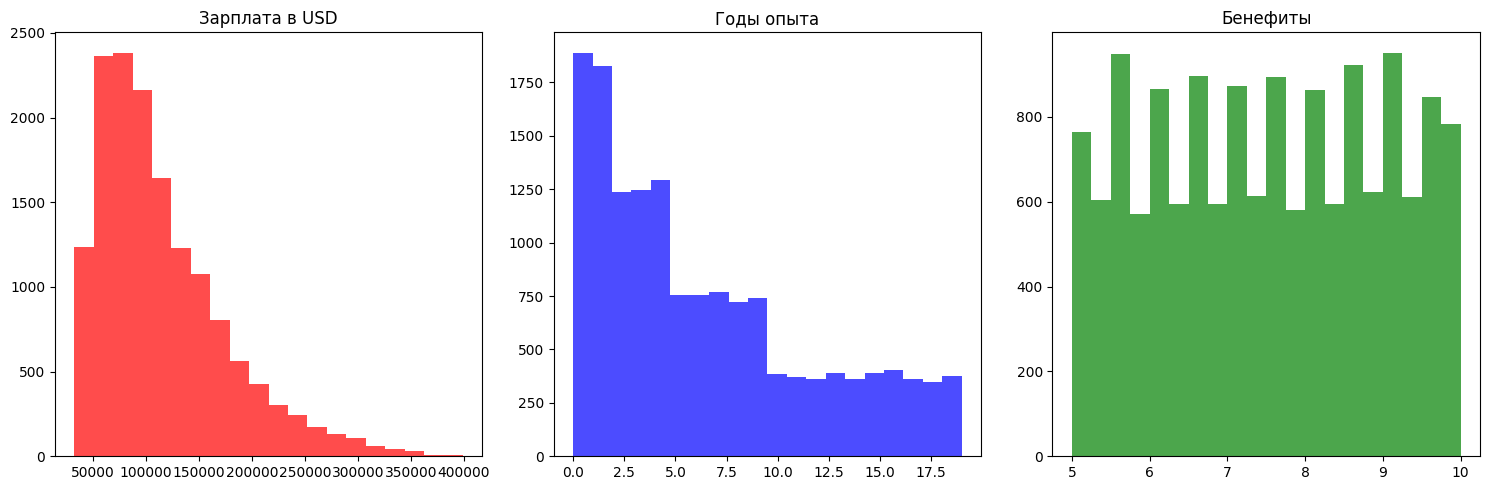

In [158]:
# код здесь ( ੭ ･ᴗ･ )੭
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['salary_usd'], bins=20, color='red', alpha=0.7)
plt.title('Зарплата в USD')

plt.subplot(1, 3, 2)
plt.hist(df['years_experience'], bins=20, color='blue', alpha=0.7)
plt.title('Годы опыта')

plt.subplot(1, 3, 3)
plt.hist(df['benefits_score'], bins=20, color='green', alpha=0.7)
plt.title('Бенефиты')

plt.tight_layout()
plt.show()

### Альтернативное решение без использования библиотеки matplotlib

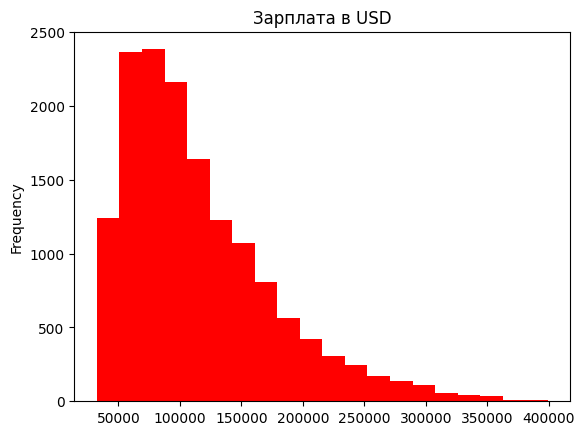

In [159]:
hist_salary = df['salary_usd'].plot(kind='hist', bins=20, color='red', title='Зарплата в USD')

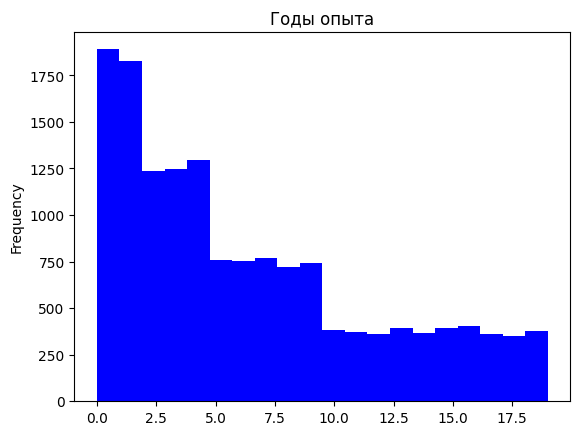

In [160]:
hist_exp = df['years_experience'].plot(kind='hist', bins=20, color='blue', title='Годы опыта')

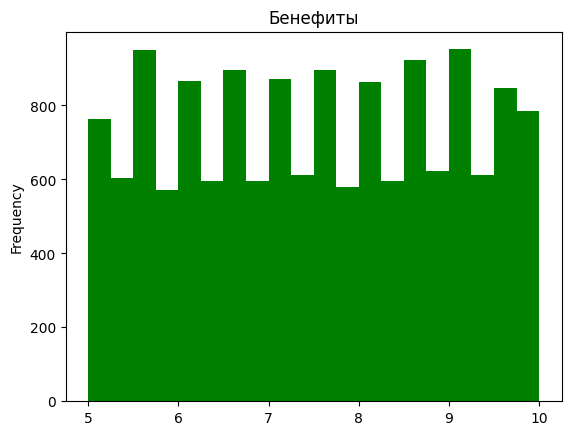

In [161]:
hist_benefits = df['benefits_score'].plot(kind='hist', bins=20, color='green', title='Бенефиты')

17. Постройте диаграмму, демонстрирующую взаимосвязь между размером компании и заработной платой. Добавьте название диаграмме и подписи осям. Обоснуйте выбор диаграммы и прокомментируйте тенденции и взаимосвязи, которые на ней отображены.

Диаграмма ящик с усами наглядно показывает медиану, квартили и разброс данных, визуализирует выбросы, позволяет сравнивать распределения между различными категориями. 

<Figure size 1000x600 with 0 Axes>

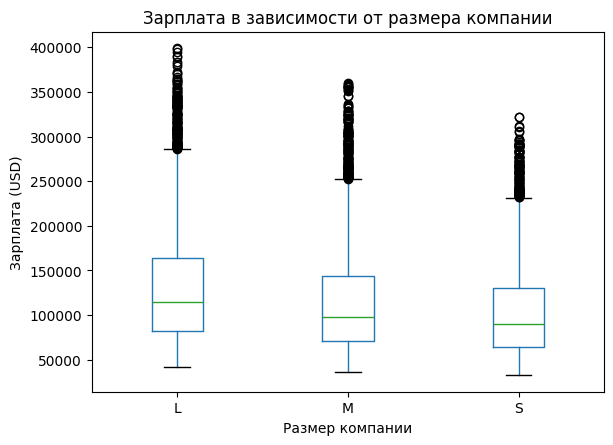

In [162]:
# код здесь ʕ•́ᴥ•̀ʔ
plt.figure(figsize=(10, 6))
df.boxplot(column='salary_usd', by='company_size', grid=False)

plt.title('Зарплата в зависимости от размера компании')
plt.suptitle('')
plt.xlabel('Размер компании')
plt.ylabel('Зарплата (USD)')
plt.show()

### Альтернативное решение без использования библиотеки matplotlib

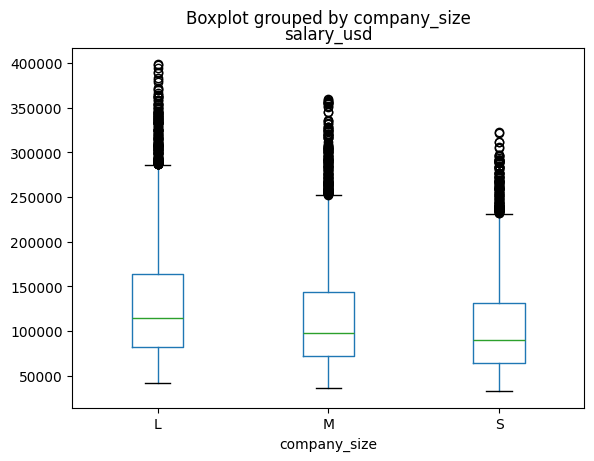

In [163]:
salary_by_size = df.boxplot(column='salary_usd', by='company_size', grid=False)

18. Постройте ящичковую диаграмму заработной платы. Наблюдаются ли выбросы?

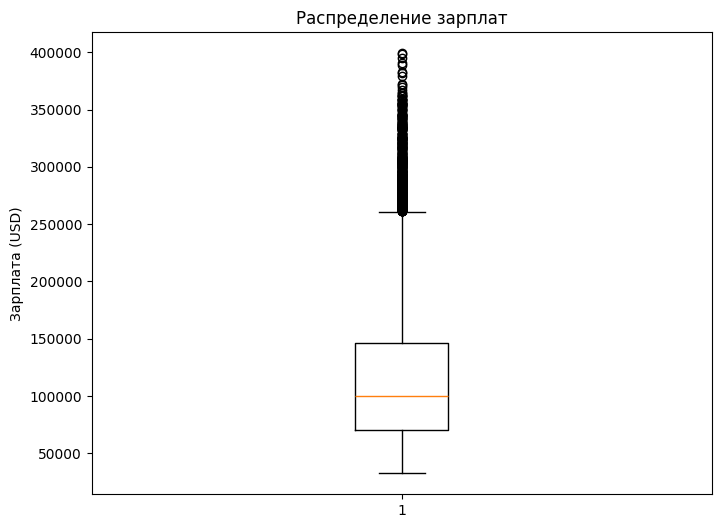

In [164]:
# код здесь (*‿*✿) 
plt.figure(figsize=(8, 6))
plt.boxplot(df['salary_usd'])
plt.title('Распределение зарплат')
plt.ylabel('Зарплата (USD)')
plt.show()  # Да, выбросы наблюдаются

### Альтернативное решение без использования библиотеки matplotlib

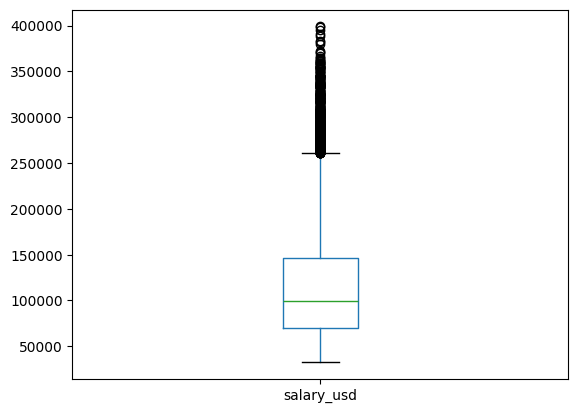

In [165]:
salary_boxplot = df.boxplot(column='salary_usd', grid=False)

19. Определите топ-5 стран по количеству вакансий. Визуализируйте это с помощью столбчатой диаграммы.

company_location
Germany    814
Denmark    778
Canada     769
France     769
Austria    765
Name: count, dtype: int64


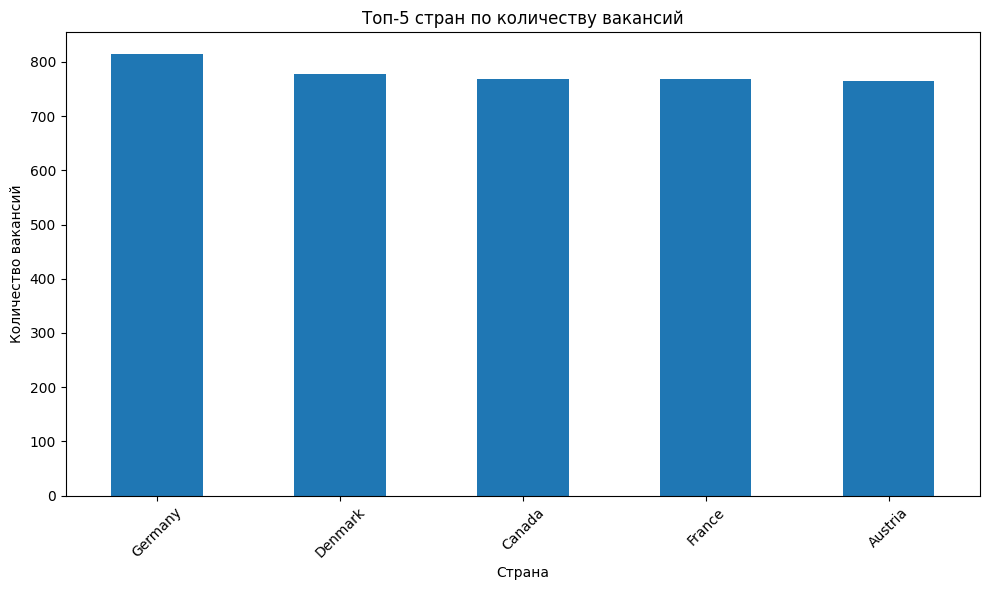

In [166]:
# код здесь ☆*:.｡.o(≧▽≦)o.｡.:*☆
top_countries = df['company_location'].value_counts().head(5)
print(top_countries)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar')
plt.title('Топ-5 стран по количеству вакансий')
plt.xlabel('Страна')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Альтернативное решение без использования библиотеки matplotlib

<Axes: title={'center': 'Топ-5 стран по количеству вакансий'}, xlabel='Страна', ylabel='Количество вакансий'>

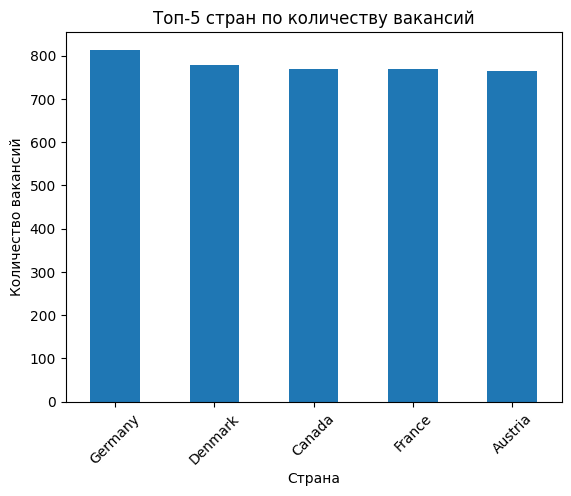

In [167]:
top_countries.plot(kind='bar', title='Топ-5 стран по количеству вакансий', 
                  xlabel='Страна', ylabel='Количество вакансий', rot=45)

20. Как связаны формат работы и зарплата? Кто получает больше — офисные, гибридные или полностью удалённые работники? Отличаются ли эти тенденции по странам?

Удаленные работники получают больше, чем офисные (на 3 месте) и гибридные (на 2 месте) сотрудники. 
- В Германии удаленные сотрудники получают сильно больше других, гибридные сотрудники получают чуть больше офисных.
- В Дании удаленные сотрудники получают меньше гибридных, но больше офисных. 
- В Канаде наибольше зарплаты у офисных сотрудников, затем у удаленных, и затем у гибирдных.

In [168]:
# код здесь (^◕ᴥ◕^)
remote_salary = df.groupby('remote_ratio')['salary_usd'].mean()
print("Средняя зарплата по формату работы:")
print((remote_salary).round(2))

top_countries_list = top_countries.index.tolist()

for country in top_countries_list[:3]:  # анализируем топ-3 страны
    country_data = df[df['company_location'] == country]
    remote_salary_country = country_data.groupby('remote_ratio')['salary_usd'].mean()
    print(f"\nСредняя зарплата по формату работы в {country}:")
    print((remote_salary_country).round(2))

Средняя зарплата по формату работы:
remote_ratio
0      114140.23
50     115776.81
100    116160.55
Name: salary_usd, dtype: float64

Средняя зарплата по формату работы в Germany:
remote_ratio
0      116345.08
50     118972.32
100    131403.40
Name: salary_usd, dtype: float64

Средняя зарплата по формату работы в Denmark:
remote_ratio
0      163423.71
50     171369.38
100    161982.62
Name: salary_usd, dtype: float64

Средняя зарплата по формату работы в Canada:
remote_ratio
0      114423.85
50     112386.79
100    115970.58
Name: salary_usd, dtype: float64


## Дополнительные задания
21. Определите топ-5 компаний с наибольшим количеством вакансий.

In [169]:
top_companies = df['company_name'].value_counts().head(5)
print(top_companies)

company_name
TechCorp Inc                  980
Cognitive Computing           972
AI Innovations                964
Digital Transformation LLC    961
Quantum Computing Inc         960
Name: count, dtype: int64


22. Рассчитайте среднюю зарплату по отраслям.

In [170]:
industry_salary = df.groupby('industry_comp')['salary_usd'].mean().sort_values(ascending=False)
print((industry_salary).round(2))

industry_comp
Consulting            117602.14
Manufacturing         116162.89
Media                 116127.73
Education             116026.80
Real Estate           115919.10
Technology            115831.82
Government            115694.32
Finance               115323.40
Telecommunications    115291.41
Energy                115188.44
Transportation        114837.80
Retail                114776.36
Healthcare            114433.88
Automotive            113987.24
Gaming                112979.57
Name: salary_usd, dtype: float64


23. Определите топ-10 наиболее востребованных навыков.

In [171]:
all_skills = []
for skills in df['required_skills']:
    all_skills.extend([skill.strip() for skill in skills.split(',')])

# Считаем частоту навыков
from collections import Counter
skill_counts = Counter(all_skills)
for skill, count in skill_counts.most_common(10):
    print(f"{skill}: {count}")

Python: 4450
SQL: 3407
TensorFlow: 3022
Kubernetes: 3009
Scala: 2794
PyTorch: 2777
Linux: 2705
Git: 2631
Java: 2578
GCP: 2442


24. Проанализируйте связь уровня образования и зарплаты.

In [172]:
education_salary = df.groupby('education_required')['salary_usd'].agg(['mean', 'median', 'count'])
print((education_salary).round(2))

                         mean    median  count
education_required                            
Associate           114605.71   99139.0   3785
Bachelor            115861.63   99087.0   3789
Master              117171.82  102553.5   3748
PhD                 113728.17   97171.5   3678


25. Найдите средний уровень удаленности работы по странам.

In [173]:
remote_by_country = df.groupby('company_location')['remote_ratio'].mean().sort_values(ascending=False)
print((remote_by_country.head(10)).round(2))

company_location
Ireland      51.87
Sweden       51.13
India        51.13
Austria      50.85
Australia    50.82
China        50.52
Denmark      50.19
Israel       50.00
Canada       49.93
France       49.67
Name: remote_ratio, dtype: float64


26. Проанализируйте бонусы по типам занятости.

In [174]:
benefits_by_employment = df.groupby('employment_type')['benefits_score'].mean()
print((benefits_by_employment).round(2))

employment_type
CT    7.47
FL    7.52
FT    7.50
PT    7.53
Name: benefits_score, dtype: float64


27. Определите самые высокооплачиваемые должности.

In [175]:
top_jobs = df.groupby('job_title')['salary_usd'].mean().nlargest(5)
print((top_jobs).round(2))

job_title
AI Specialist                120570.76
Machine Learning Engineer    118827.92
Head of AI                   118542.97
AI Research Scientist        117897.93
AI Architect                 117436.51
Name: salary_usd, dtype: float64


28. Проанализируйте зависимость зарплаты от опыта.

In [176]:
exp_salary_corr = df['years_experience'].corr(df['salary_usd'])
print(f"Корреляция между опытом и зарплатой: {exp_salary_corr:.3f}")

Корреляция между опытом и зарплатой: 0.738


**Комментарии к заданию и принципам его оценивания:**

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов описательного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 21 октября.